In [180]:
import numpy as np
import pandas as pd

df = pd.read_csv(r"C:\Users\WEWL\OneDrive - Capco\Desktop\ADS Assessment\Data\Classification_train.csv")
print(df.head())

       ID Customer_ID     Month           Name   Age          SSN Occupation  \
0  0x1602   CUS_0xd40   January  Aaron Maashoh    23  821-00-0265  Scientist   
1  0x1603   CUS_0xd40  February  Aaron Maashoh    23  821-00-0265  Scientist   
2  0x1604   CUS_0xd40     March  Aaron Maashoh  -500  821-00-0265  Scientist   
3  0x1605   CUS_0xd40     April  Aaron Maashoh    23  821-00-0265  Scientist   
4  0x1606   CUS_0xd40       May  Aaron Maashoh    23  821-00-0265  Scientist   

  Annual_Income  Monthly_Inhand_Salary  Num_Bank_Accounts  ...  Credit_Mix  \
0      19114.12            1824.843333                  3  ...           _   
1      19114.12                    NaN                  3  ...        Good   
2      19114.12                    NaN                  3  ...        Good   
3      19114.12                    NaN                  3  ...        Good   
4      19114.12            1824.843333                  3  ...        Good   

   Outstanding_Debt Credit_Utilization_Ratio     C

C:\Users\WEWL\AppData\Local\Temp\ipykernel_2392\1291722512.py:4: DtypeWarning: Columns (26) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(r"C:\Users\WEWL\OneDrive - Capco\Desktop\ADS Assessment\Data\Classification_train.csv")


In [181]:
print(df.shape)
x, y = df.shape
print(f"Number of data points: {x*y}")
print(df.describe(include=object))
print(df.describe().T.round(2))

(100000, 28)
Number of data points: 2800000
            ID Customer_ID    Month    Name     Age        SSN Occupation  \
count   100000      100000   100000   90015  100000     100000     100000   
unique  100000       12500        8   10139    1788      12501         16   
top     0x1602   CUS_0xd40  January  Stevex      38  #F%$D@*&8    _______   
freq         1           8    12500      44    2833       5572       7062   

       Annual_Income Num_of_Loan   Type_of_Loan Num_of_Delayed_Payment  \
count         100000      100000          88592                  92998   
unique         18940         434           6260                    749   
top         17273.83           3  Not Specified                     19   
freq              16       14386           1408                   5327   

       Changed_Credit_Limit Credit_Mix Outstanding_Debt  \
count                100000     100000           100000   
unique                 4384          4            13178   
top                   

In [182]:
#Doesn't seems important for analysis, keeping customer ID to map customer data to fill NA
df = df.drop(["ID","Month","Name","SSN"], axis=1)

In [183]:
df.dtypes

Customer_ID                  object
Age                          object
Occupation                   object
Annual_Income                object
Monthly_Inhand_Salary       float64
Num_Bank_Accounts             int64
Num_Credit_Card               int64
Interest_Rate                 int64
Num_of_Loan                  object
Type_of_Loan                 object
Delay_from_due_date           int64
Num_of_Delayed_Payment       object
Changed_Credit_Limit         object
Num_Credit_Inquiries        float64
Credit_Mix                   object
Outstanding_Debt             object
Credit_Utilization_Ratio    float64
Credit_History_Age           object
Payment_of_Min_Amount        object
Total_EMI_per_month         float64
Amount_invested_monthly      object
Payment_Behaviour            object
Monthly_Balance              object
Credit_Score                 object
dtype: object

In [184]:
#Converting Credit Age to int from object 

import re
def convert_credit_history(text):
    if pd.isna(text):
        return np.nan
    
    match = re.search(r"(\d+)\s+Years?\s+and\s+(\d+)\s+Months?", str(text))
    if match:
        years = int(match.group(1))
        months = int(match.group(2))
        return years * 12 + months
    
    return np.nan

df["Credit_History_Age"] = df["Credit_History_Age"].apply(convert_credit_history)

In [185]:
#Converting numerical values from objects to int/floats 
numeric_cols = [
   'Age','Annual_Income','Monthly_Inhand_Salary','Num_Bank_Accounts','Num_Credit_Card','Interest_Rate','Num_of_Loan','Delay_from_due_date','Num_of_Delayed_Payment','Changed_Credit_Limit','Num_Credit_Inquiries','Outstanding_Debt','Credit_Utilization_Ratio','Credit_History_Age','Total_EMI_per_month','Amount_invested_monthly','Monthly_Balance'
]

for col in numeric_cols:
    df[col] = df[col].astype(str).str.strip()
    df[col] = df[col].str.rstrip("_")
    df[col] = df[col].str.replace(",", "", regex=False)
    df[col] = pd.to_numeric(df[col], errors="coerce")

In [186]:
df.dtypes

Customer_ID                  object
Age                           int64
Occupation                   object
Annual_Income               float64
Monthly_Inhand_Salary       float64
Num_Bank_Accounts             int64
Num_Credit_Card               int64
Interest_Rate                 int64
Num_of_Loan                   int64
Type_of_Loan                 object
Delay_from_due_date           int64
Num_of_Delayed_Payment      float64
Changed_Credit_Limit        float64
Num_Credit_Inquiries        float64
Credit_Mix                   object
Outstanding_Debt            float64
Credit_Utilization_Ratio    float64
Credit_History_Age          float64
Payment_of_Min_Amount        object
Total_EMI_per_month         float64
Amount_invested_monthly     float64
Payment_Behaviour            object
Monthly_Balance             float64
Credit_Score                 object
dtype: object

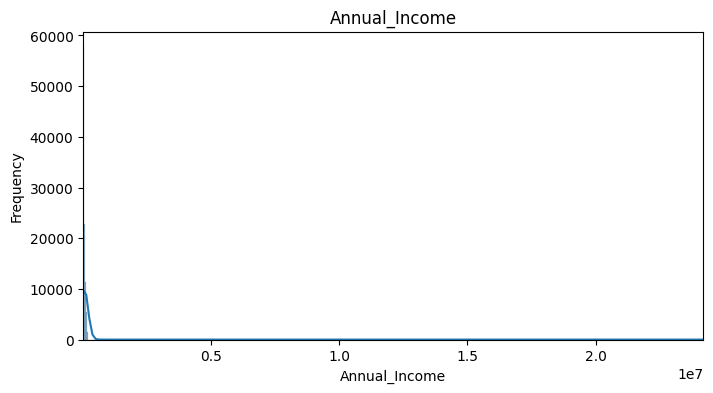

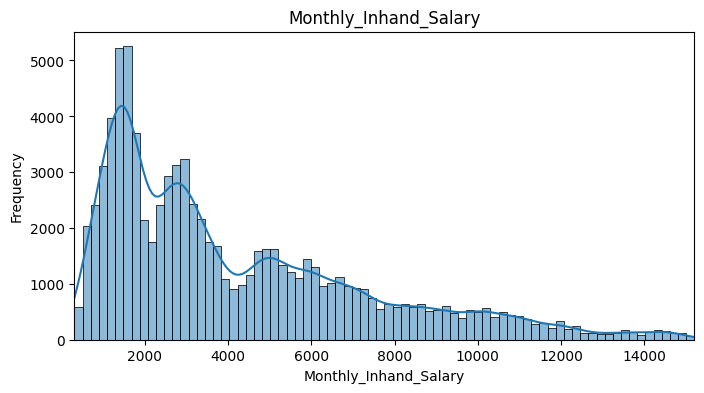

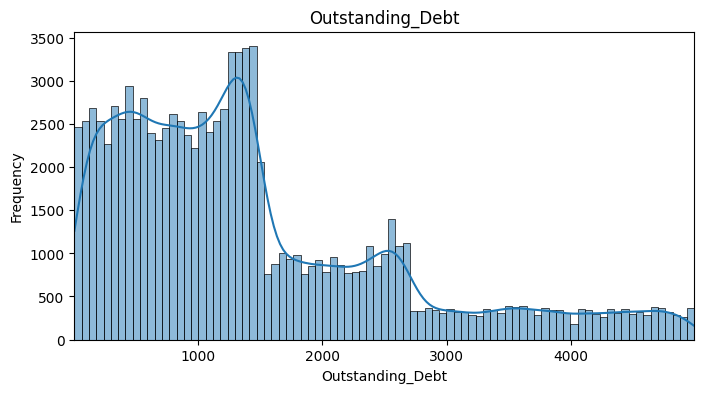

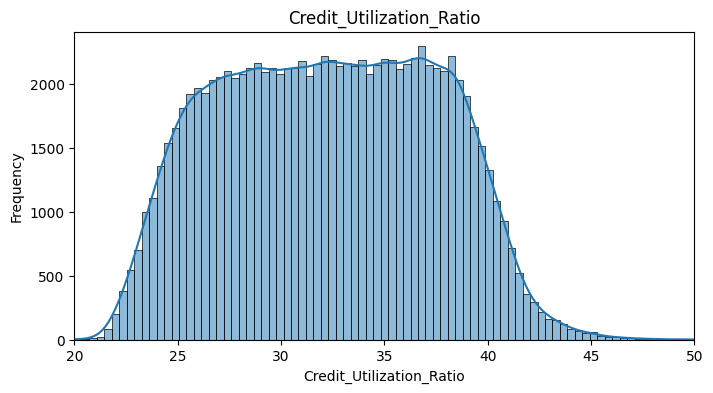

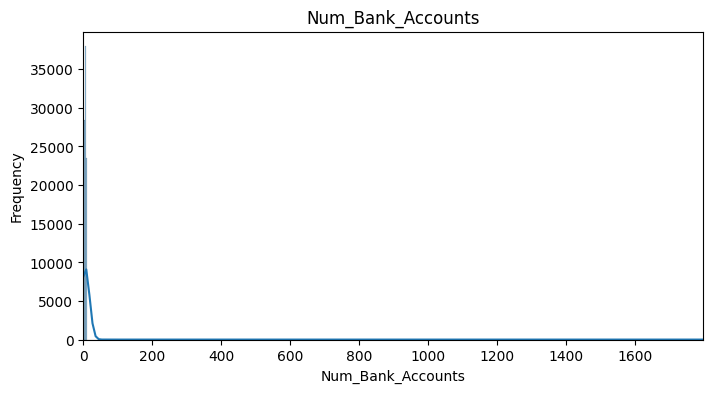

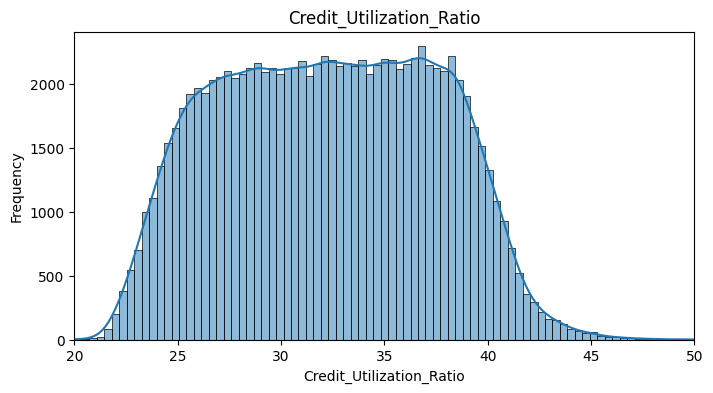

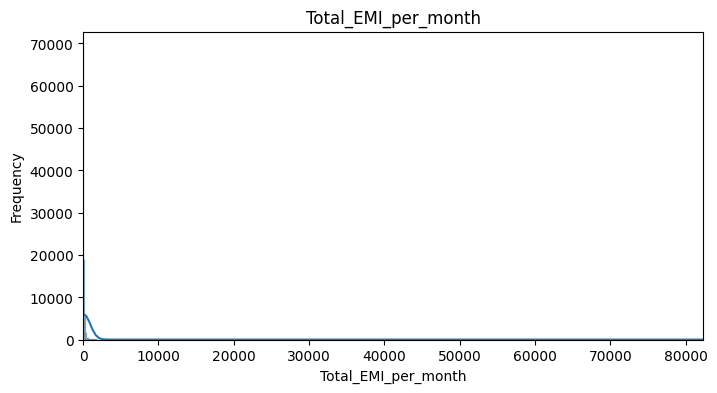

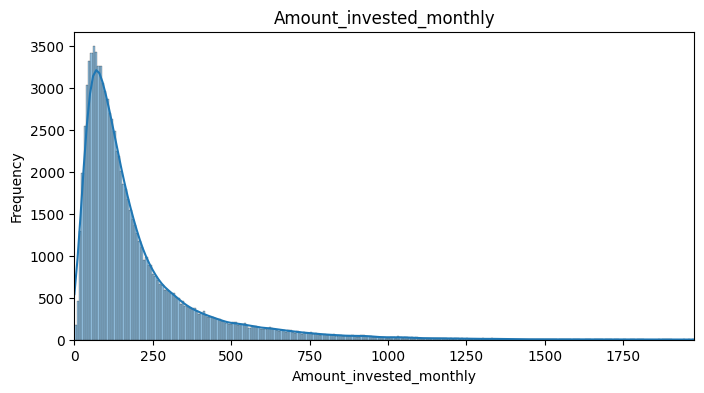

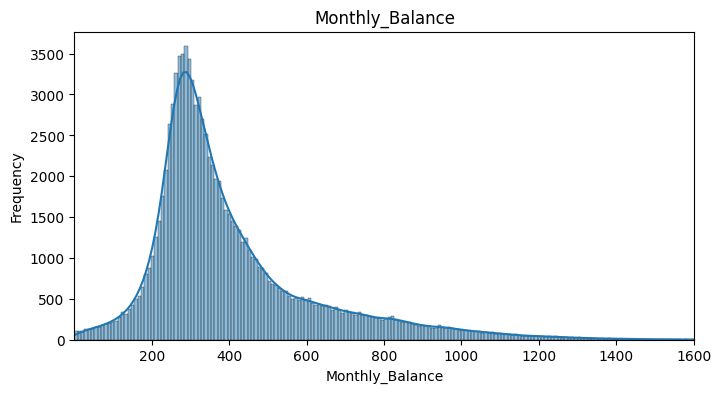

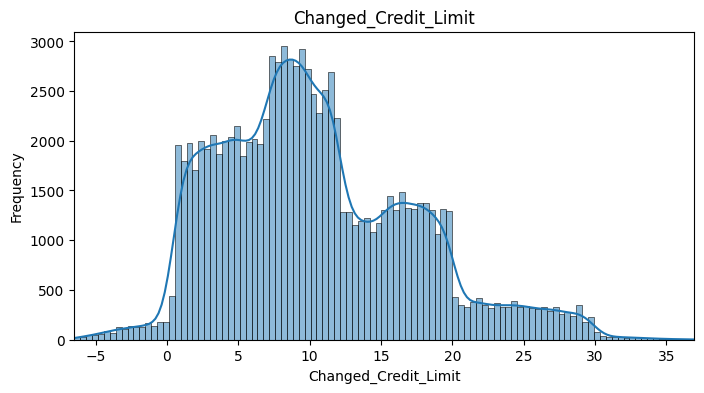

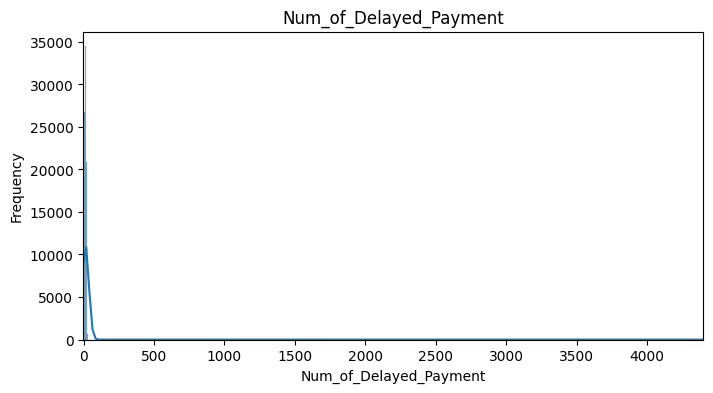

In [187]:
import seaborn as sns
import matplotlib.pyplot as plt

def plot_distribution(column, title):
    plt.figure(figsize=(8, 4))
    sns.histplot(data=df, x=column, kde=True)
    plt.title(title)
    plt.xlim(df[column].min(), df[column].dropna().max())
    plt.xlabel(column)
    plt.ylabel('Frequency')
    plt.show()

plot_distribution("Annual_Income","Annual_Income")
plot_distribution("Monthly_Inhand_Salary","Monthly_Inhand_Salary")
plot_distribution("Outstanding_Debt","Outstanding_Debt")
plot_distribution("Credit_Utilization_Ratio","Credit_Utilization_Ratio")
plot_distribution("Num_Bank_Accounts","Num_Bank_Accounts")
plot_distribution("Credit_Utilization_Ratio","Credit_Utilization_Ratio")
plot_distribution("Total_EMI_per_month","Total_EMI_per_month")
plot_distribution("Amount_invested_monthly","Amount_invested_monthly")
plot_distribution("Monthly_Balance","Monthly_Balance")
plot_distribution("Changed_Credit_Limit","Changed_Credit_Limit")
plot_distribution("Num_of_Delayed_Payment","Num_of_Delayed_Payment")

In [188]:
null_count = df.isnull().sum()
print(null_count)
print(f"There is {null_count.sum()} null data points in the data")

Customer_ID                     0
Age                             0
Occupation                      0
Annual_Income                   0
Monthly_Inhand_Salary       15002
Num_Bank_Accounts               0
Num_Credit_Card                 0
Interest_Rate                   0
Num_of_Loan                     0
Type_of_Loan                11408
Delay_from_due_date             0
Num_of_Delayed_Payment       7002
Changed_Credit_Limit         2091
Num_Credit_Inquiries         1965
Credit_Mix                      0
Outstanding_Debt                0
Credit_Utilization_Ratio        0
Credit_History_Age           9030
Payment_of_Min_Amount           0
Total_EMI_per_month             0
Amount_invested_monthly      8784
Payment_Behaviour               0
Monthly_Balance              1209
Credit_Score                    0
dtype: int64
There is 56491 null data points in the data


In [189]:
def number_loans(df):
    df["no_of_loan"] = df["Type_of_Loan"].fillna("").apply(
        lambda x: 0 if x.strip() == "" else x.count(",") + 1
    )
    df.drop(["Type_of_Loan", "Num_of_Loan"], axis=1, inplace=True)

number_loans(df)





In [190]:
def clean_group_numeric(series):
    valid = series.dropna()
    if len(valid) < 4:
        return series

    q1 = valid.quantile(0.25)
    q3 = valid.quantile(0.75)
    iqr = q3 - q1

    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    median_value = valid.median()

    series = series.apply(
        lambda x: median_value if pd.notna(x) and (x < lower or x > upper) else x
    )

    series = series.fillna(median_value)
    return series

numeric_cols=df.select_dtypes(include="number").columns.tolist()

for col in numeric_cols:
    df[col] = df.groupby("Customer_ID")[col].transform(clean_group_numeric)

In [191]:
#outlier_cols = ["Annual_Income","Num_Bank_Accounts","Total_EMI_per_month","Num_of_Delayed_Payment"]

#for col in outlier_cols:
    #upper = df[col].quantile(0.95)
    #df[col] = df[col].clip(upper=upper)

In [192]:
null_count = df.isnull().sum()
print(null_count)
print(f"There is {null_count.sum()} null data points in the data")

Customer_ID                   0
Age                           0
Occupation                    0
Annual_Income                 0
Monthly_Inhand_Salary       228
Num_Bank_Accounts             0
Num_Credit_Card               0
Interest_Rate                 0
Delay_from_due_date           0
Num_of_Delayed_Payment        5
Changed_Credit_Limit          0
Num_Credit_Inquiries          0
Credit_Mix                    0
Outstanding_Debt              0
Credit_Utilization_Ratio      0
Credit_History_Age           10
Payment_of_Min_Amount         0
Total_EMI_per_month           0
Amount_invested_monthly      15
Payment_Behaviour             0
Monthly_Balance               5
Credit_Score                  0
no_of_loan                    0
dtype: int64
There is 263 null data points in the data


C:\Users\WEWL\AppData\Local\Temp\ipykernel_2392\2664074748.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=column,palette="flare")


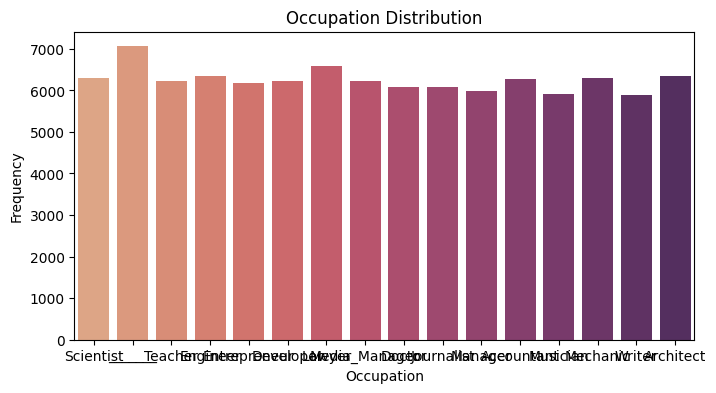

C:\Users\WEWL\AppData\Local\Temp\ipykernel_2392\2664074748.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=column,palette="flare")


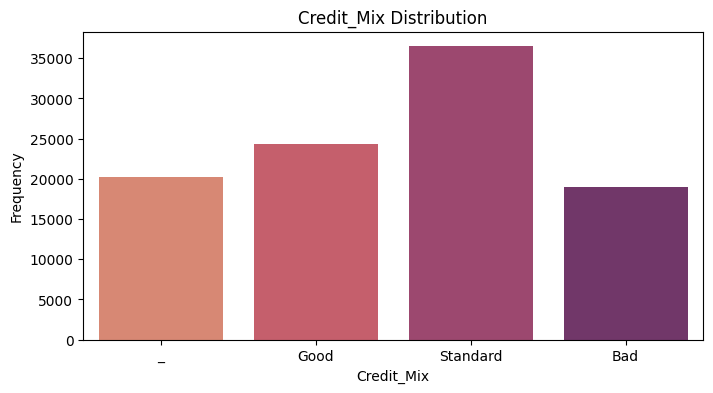

C:\Users\WEWL\AppData\Local\Temp\ipykernel_2392\2664074748.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=column,palette="flare")


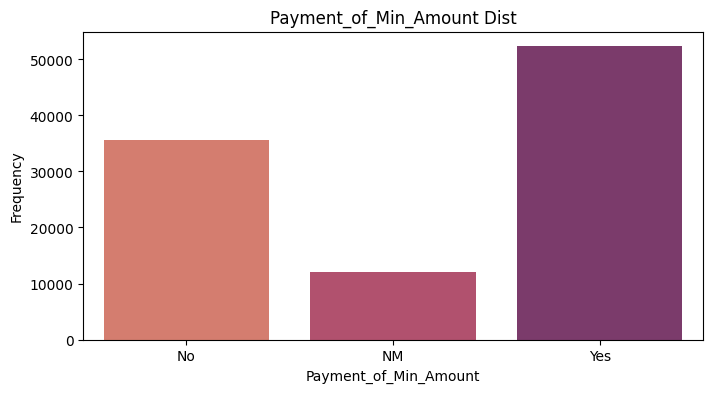

In [193]:
def plot_bar(column, title):
    plt.figure(figsize=(8, 4))
    sns.countplot(data=df, x=column,palette="flare")
    plt.title(title)
    plt.xlabel(column)
    plt.ylabel('Frequency')
    plt.show()

plot_bar("Occupation", "Occupation Distribution")
plot_bar("Credit_Mix", "Credit_Mix Distribution")
plot_bar("Payment_of_Min_Amount", "Payment_of_Min_Amount Dist")


In [194]:
df.columns

Index(['Customer_ID', 'Age', 'Occupation', 'Annual_Income',
       'Monthly_Inhand_Salary', 'Num_Bank_Accounts', 'Num_Credit_Card',
       'Interest_Rate', 'Delay_from_due_date', 'Num_of_Delayed_Payment',
       'Changed_Credit_Limit', 'Num_Credit_Inquiries', 'Credit_Mix',
       'Outstanding_Debt', 'Credit_Utilization_Ratio', 'Credit_History_Age',
       'Payment_of_Min_Amount', 'Total_EMI_per_month',
       'Amount_invested_monthly', 'Payment_Behaviour', 'Monthly_Balance',
       'Credit_Score', 'no_of_loan'],
      dtype='object')

In [195]:
df["Occupation"] = df["Occupation"].replace("_______", np.nan)
df["Credit_Mix"] = df["Credit_Mix"].replace("_", np.nan)
df["Payment_of_Min_Amount"] = df["Payment_of_Min_Amount"].replace("NM", np.nan)


for col in ["Occupation", "Credit_Mix","Payment_of_Min_Amount"]:
    df[col] = df.groupby("Customer_ID")[col].transform(
        lambda x: x.fillna(x.mode().iloc[0]) if not x.mode().empty else x
    )
    df[col] = df[col].fillna(df[col].mode()[0])

C:\Users\WEWL\AppData\Local\Temp\ipykernel_2392\2664074748.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=column,palette="flare")


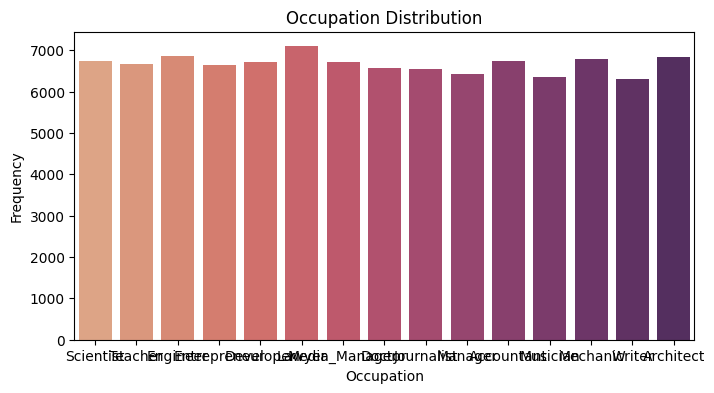

C:\Users\WEWL\AppData\Local\Temp\ipykernel_2392\2664074748.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=column,palette="flare")


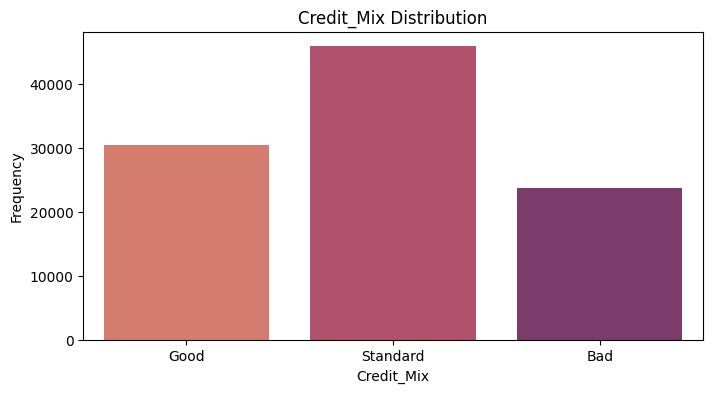

C:\Users\WEWL\AppData\Local\Temp\ipykernel_2392\2664074748.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=column,palette="flare")


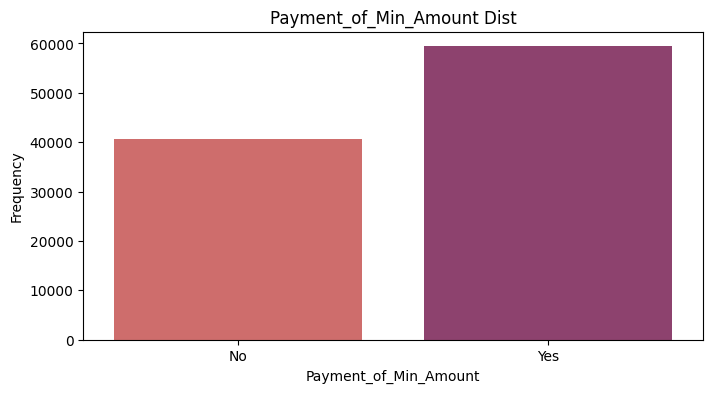

In [196]:
plot_bar("Occupation", "Occupation Distribution")
plot_bar("Credit_Mix", "Credit_Mix Distribution")
plot_bar("Payment_of_Min_Amount", "Payment_of_Min_Amount Dist")

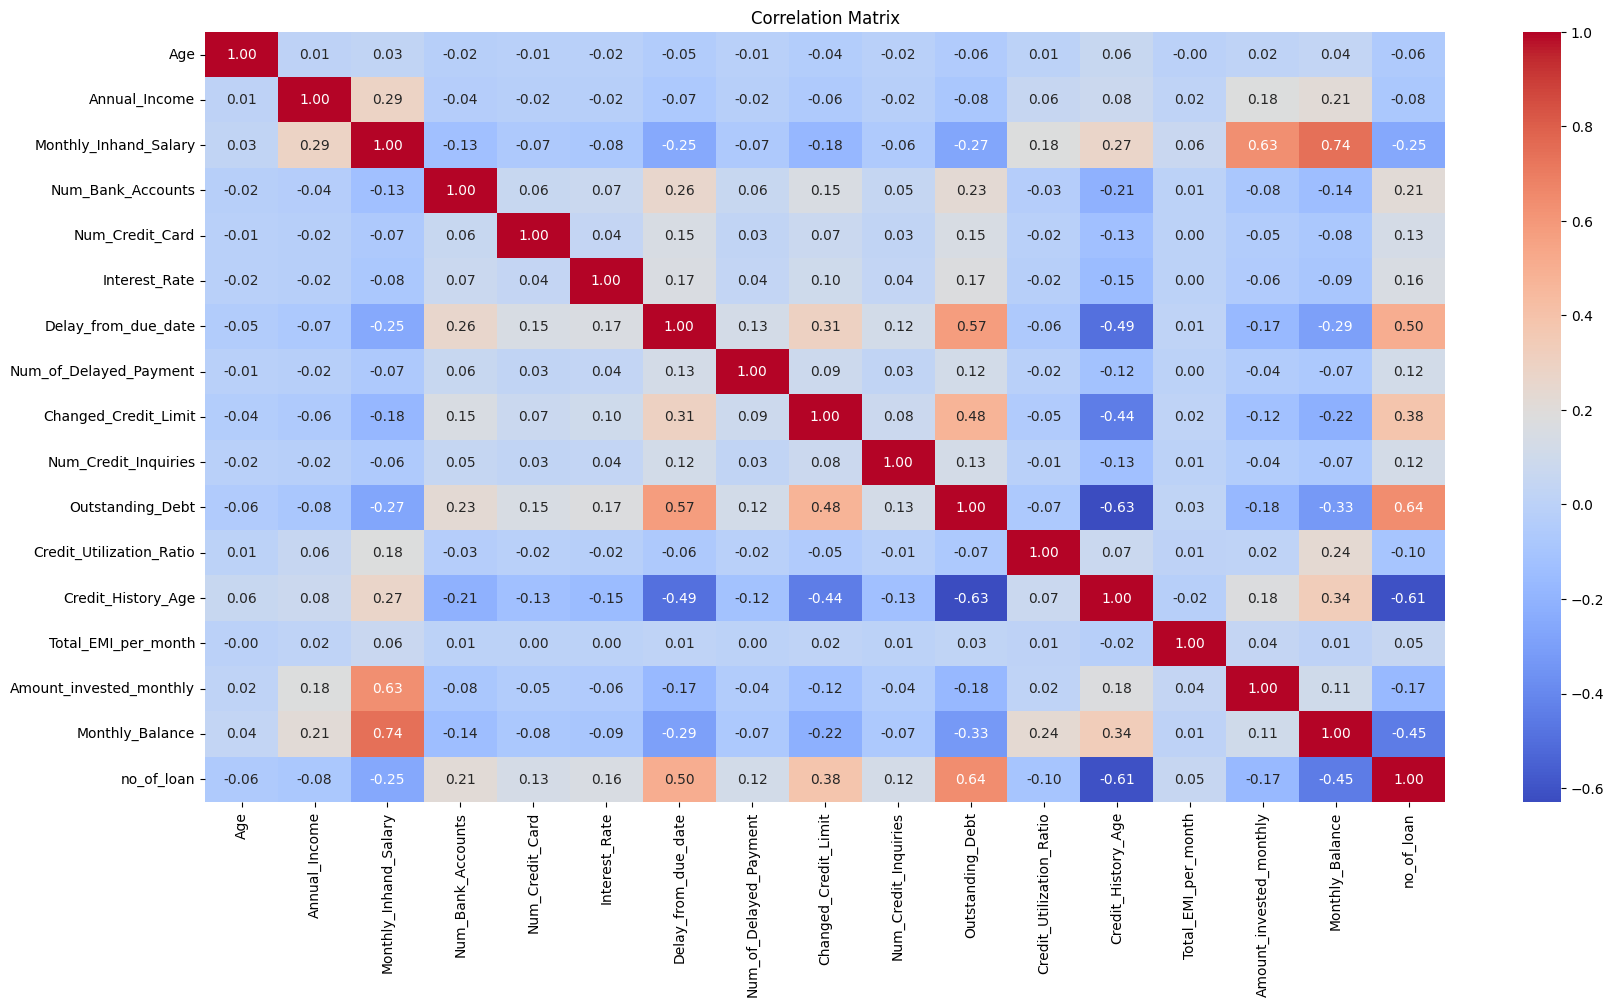

In [197]:
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(20, 10))
corr = df.corr(numeric_only=True)
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

In [198]:
df=df.dropna(axis=0)
print(df.isnull().sum())


Customer_ID                 0
Age                         0
Occupation                  0
Annual_Income               0
Monthly_Inhand_Salary       0
Num_Bank_Accounts           0
Num_Credit_Card             0
Interest_Rate               0
Delay_from_due_date         0
Num_of_Delayed_Payment      0
Changed_Credit_Limit        0
Num_Credit_Inquiries        0
Credit_Mix                  0
Outstanding_Debt            0
Credit_Utilization_Ratio    0
Credit_History_Age          0
Payment_of_Min_Amount       0
Total_EMI_per_month         0
Amount_invested_monthly     0
Payment_Behaviour           0
Monthly_Balance             0
Credit_Score                0
no_of_loan                  0
dtype: int64


In [199]:
from sklearn.preprocessing import StandardScaler

numeric_cols = df.select_dtypes(include=["int64", "float64"]).columns

scaler = StandardScaler()
df[numeric_cols] = scaler.fit_transform(df[numeric_cols])

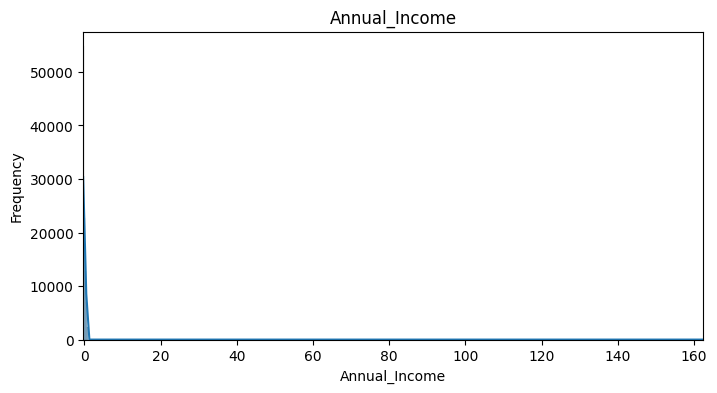

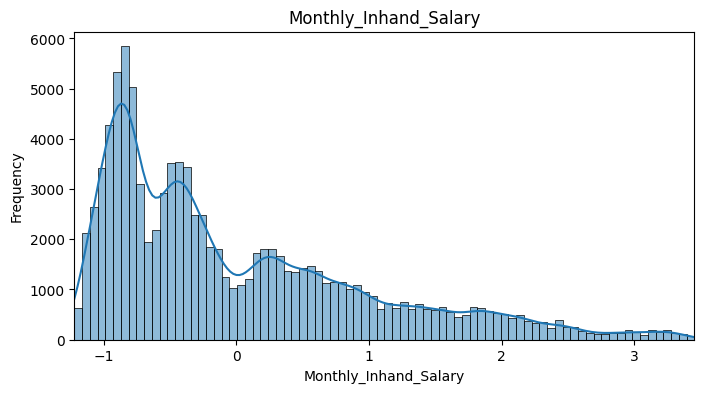

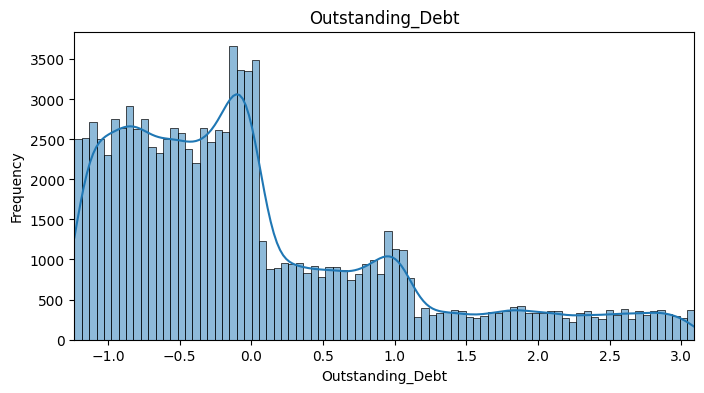

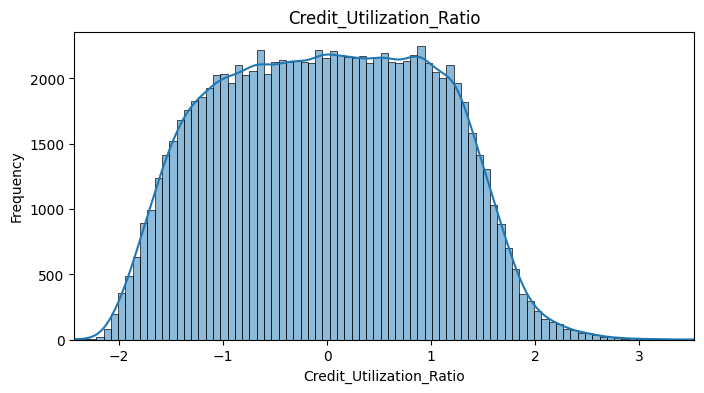

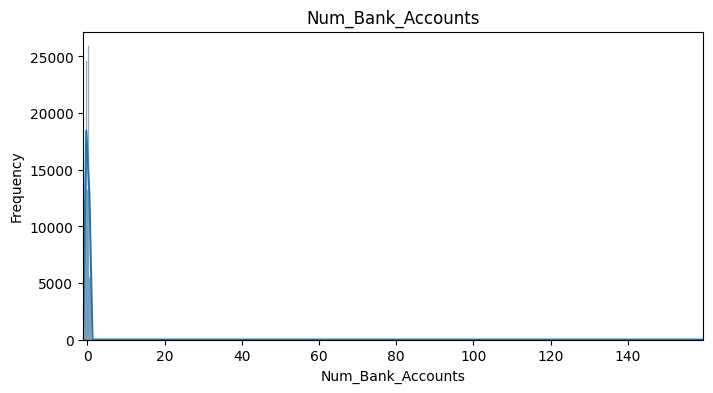

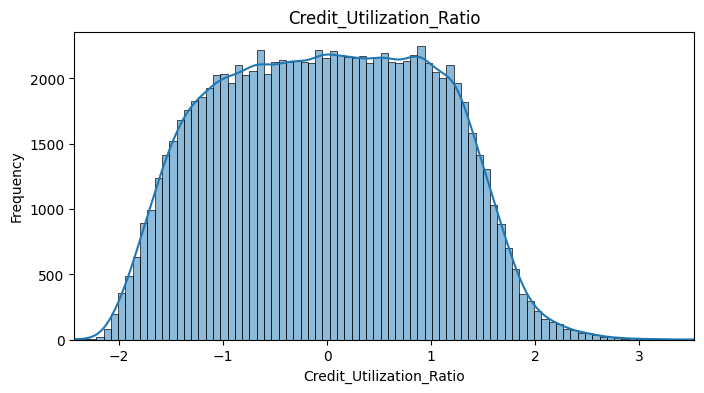

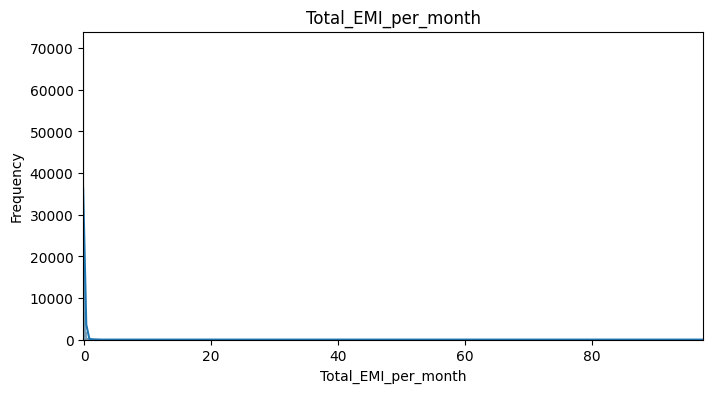

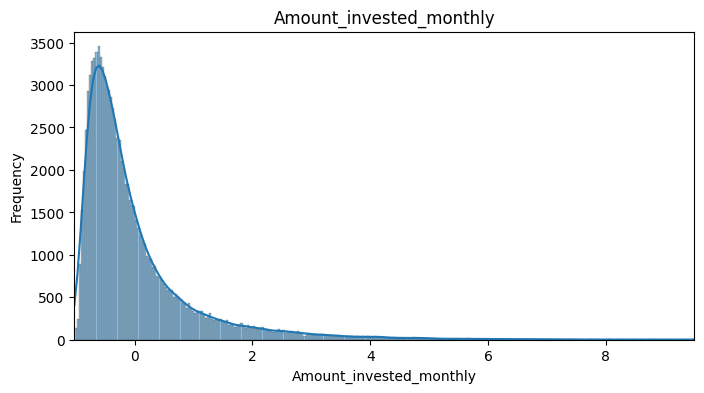

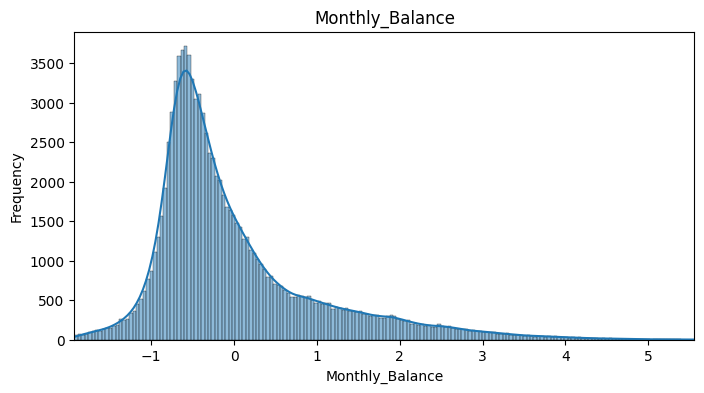

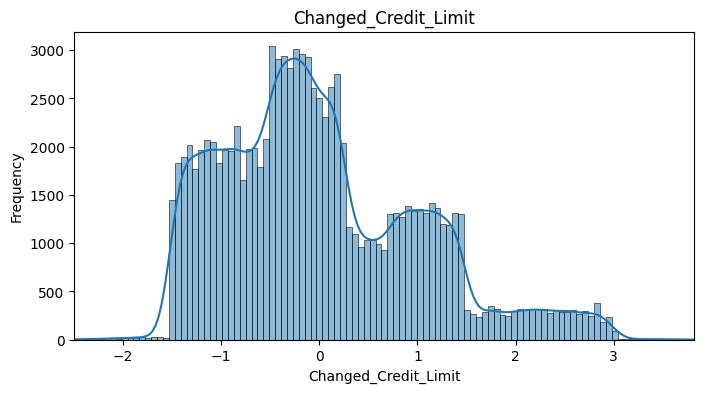

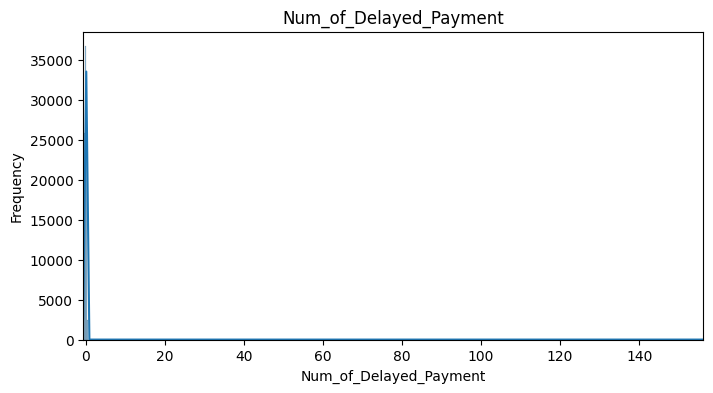

In [200]:
plot_distribution("Annual_Income","Annual_Income")
plot_distribution("Monthly_Inhand_Salary","Monthly_Inhand_Salary")
plot_distribution("Outstanding_Debt","Outstanding_Debt")
plot_distribution("Credit_Utilization_Ratio","Credit_Utilization_Ratio")
plot_distribution("Num_Bank_Accounts","Num_Bank_Accounts")
plot_distribution("Credit_Utilization_Ratio","Credit_Utilization_Ratio")
plot_distribution("Total_EMI_per_month","Total_EMI_per_month")
plot_distribution("Amount_invested_monthly","Amount_invested_monthly")
plot_distribution("Monthly_Balance","Monthly_Balance")
plot_distribution("Changed_Credit_Limit","Changed_Credit_Limit")
plot_distribution("Num_of_Delayed_Payment","Num_of_Delayed_Payment")

In [201]:
df['Payment_Behaviour'] = df['Payment_Behaviour'].replace(['!@9#%8'], np.nan)

df["Payment_Behaviour"] = df.groupby("Customer_ID")["Payment_Behaviour"].transform(
    lambda x: x.fillna(x.mode().iloc[0]) if not x.mode().empty else x
)

def PB_handling(df):
    df[['Spent', 'Value_Payments']] = df['Payment_Behaviour'].str.split('_', expand=True).iloc[:, [0,2]]
    df.drop(['Payment_Behaviour'], axis=1, inplace=True)

PB_handling(df)


In [202]:
def repl_values(df):
    df['Spent'] = df['Spent'].replace({'High':1, 'Low':0})
    df['Value_Payments'] = df['Value_Payments'].replace({'Small':0, 'Medium':1, 'Large':2})
    df['Credit_Mix'] =df['Credit_Mix'].replace({'Bad':0, 'Standard':1, 'Good':2})
    df['Payment_of_Min_Amount'] = df['Payment_of_Min_Amount'].replace({'Yes':1, 'No':0})

repl_values(df)


C:\Users\WEWL\AppData\Local\Temp\ipykernel_2392\2861050982.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['Spent'] = df['Spent'].replace({'High':1, 'Low':0})
C:\Users\WEWL\AppData\Local\Temp\ipykernel_2392\2861050982.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['Value_Payments'] = df['Value_Payments'].replace({'Small':0, 'Medium':1, 'Large':2})
C:\Users\WEWL\AppData\Local\Temp\ipykernel_2392\2861050982.py:4: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To

In [203]:
df =df.drop("Occupation", axis=1)

In [204]:
print(df.isnull().sum())

Customer_ID                 0
Age                         0
Annual_Income               0
Monthly_Inhand_Salary       0
Num_Bank_Accounts           0
Num_Credit_Card             0
Interest_Rate               0
Delay_from_due_date         0
Num_of_Delayed_Payment      0
Changed_Credit_Limit        0
Num_Credit_Inquiries        0
Credit_Mix                  0
Outstanding_Debt            0
Credit_Utilization_Ratio    0
Credit_History_Age          0
Payment_of_Min_Amount       0
Total_EMI_per_month         0
Amount_invested_monthly     0
Monthly_Balance             0
Credit_Score                0
no_of_loan                  0
Spent                       0
Value_Payments              0
dtype: int64


In [205]:
df.shape

(99737, 23)

C:\Users\WEWL\AppData\Local\Temp\ipykernel_2392\2664074748.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=column,palette="flare")


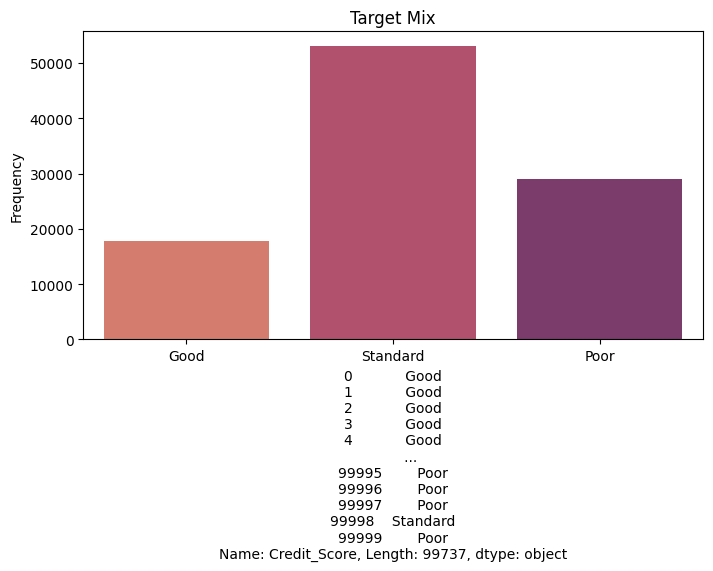

In [206]:
plot_bar(df.Credit_Score,"Target Mix")

In [207]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier

# Target and features
X = df.drop(["Credit_Score","Customer_ID"], axis=1)
y = df["Credit_Score"]

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Models
models = {
    "Logistic Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(max_iter=1000))
    ]),
    "KNN": Pipeline([
        ("scaler", StandardScaler()),
        ("model", KNeighborsClassifier(n_neighbors=5))
    ]),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42)
}

# Train and evaluate
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    print(f"\n{name}")
    print("-" * 40)
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))
    print("\nConfusion Matrix:")
    print(confusion_matrix(y_test, y_pred))


Logistic Regression
----------------------------------------
Accuracy: 0.646781632243834

Classification Report:
              precision    recall  f1-score   support

        Good       0.54      0.63      0.58      3549
        Poor       0.66      0.48      0.56      5788
    Standard       0.68      0.74      0.71     10611

    accuracy                           0.65     19948
   macro avg       0.63      0.62      0.62     19948
weighted avg       0.65      0.65      0.64     19948


Confusion Matrix:
[[2248   55 1246]
 [ 505 2765 2518]
 [1384 1338 7889]]

KNN
----------------------------------------
Accuracy: 0.6746541006617205

Classification Report:
              precision    recall  f1-score   support

        Good       0.53      0.61      0.57      3549
        Poor       0.67      0.63      0.65      5788
    Standard       0.73      0.72      0.73     10611

    accuracy                           0.67     19948
   macro avg       0.64      0.65      0.65     19948
weight

In [208]:
print(df.head())

  Customer_ID       Age  Annual_Income  Monthly_Inhand_Salary  \
0   CUS_0xd40 -0.279342      -0.239969               -0.74479   
1   CUS_0xd40 -0.279342      -0.239969               -0.74479   
2   CUS_0xd40 -0.279342      -0.239969               -0.74479   
3   CUS_0xd40 -0.279342      -0.239969               -0.74479   
4   CUS_0xd40 -0.279342      -0.239969               -0.74479   

   Num_Bank_Accounts  Num_Credit_Card  Interest_Rate  Delay_from_due_date  \
0          -0.405156        -0.225176      -0.368871            -1.222209   
1          -0.405156        -0.225176      -0.368871            -1.222209   
2          -0.405156        -0.225176      -0.368871            -1.222209   
3          -0.405156        -0.225176      -0.368871            -1.086959   
4          -0.405156        -0.225176      -0.368871            -1.019334   

   Num_of_Delayed_Payment  Changed_Credit_Limit  ...  \
0               -0.240237              0.133343  ...   
1               -0.258536         

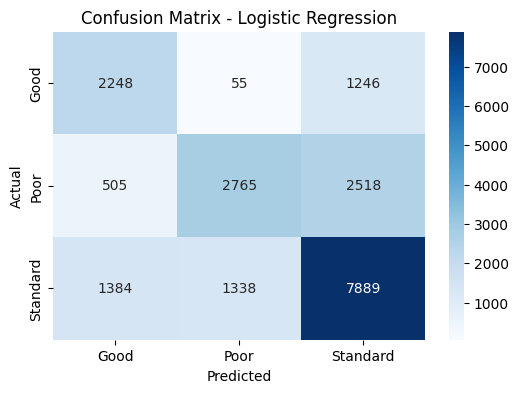

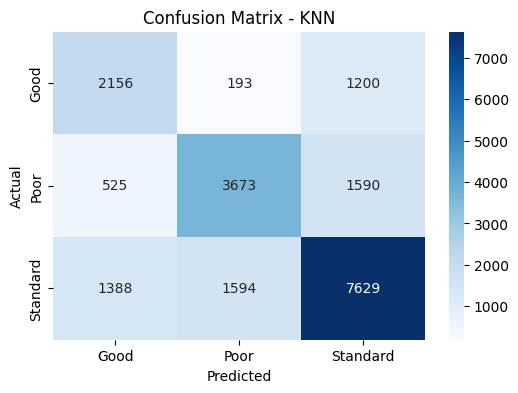

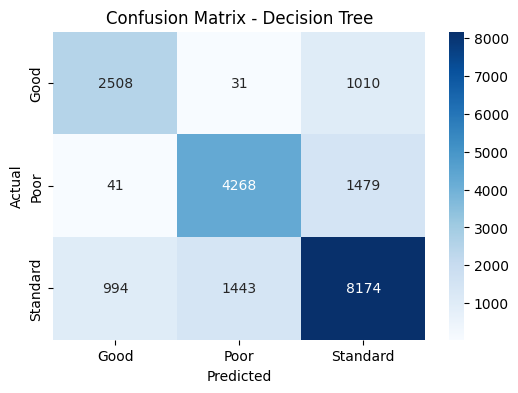

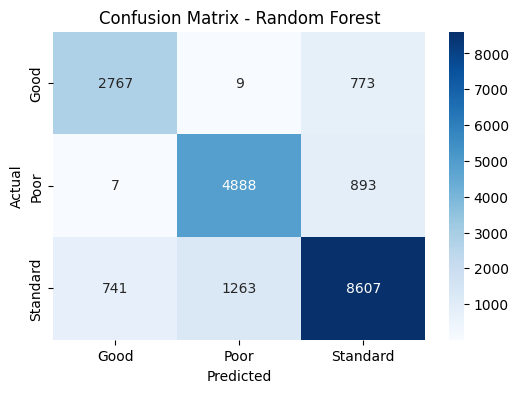

In [209]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(6, 4))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=model.classes_,
        yticklabels=model.classes_
    )
    plt.title(f"Confusion Matrix - {name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()


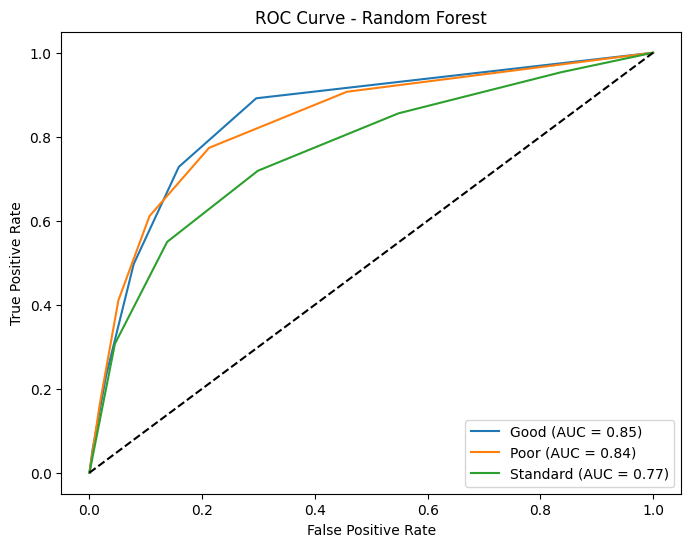

In [212]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

rf_model = models["KNN"]
y_score = rf_model.predict_proba(X_test)

classes = rf_model.classes_
y_test_bin = label_binarize(y_test, classes=classes)

plt.figure(figsize=(8, 6))

for i, class_name in enumerate(classes):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{class_name} (AUC = {roc_auc:.2f})")

plt.plot([0, 1], [0, 1], "k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Random Forest")
plt.legend()
plt.show()

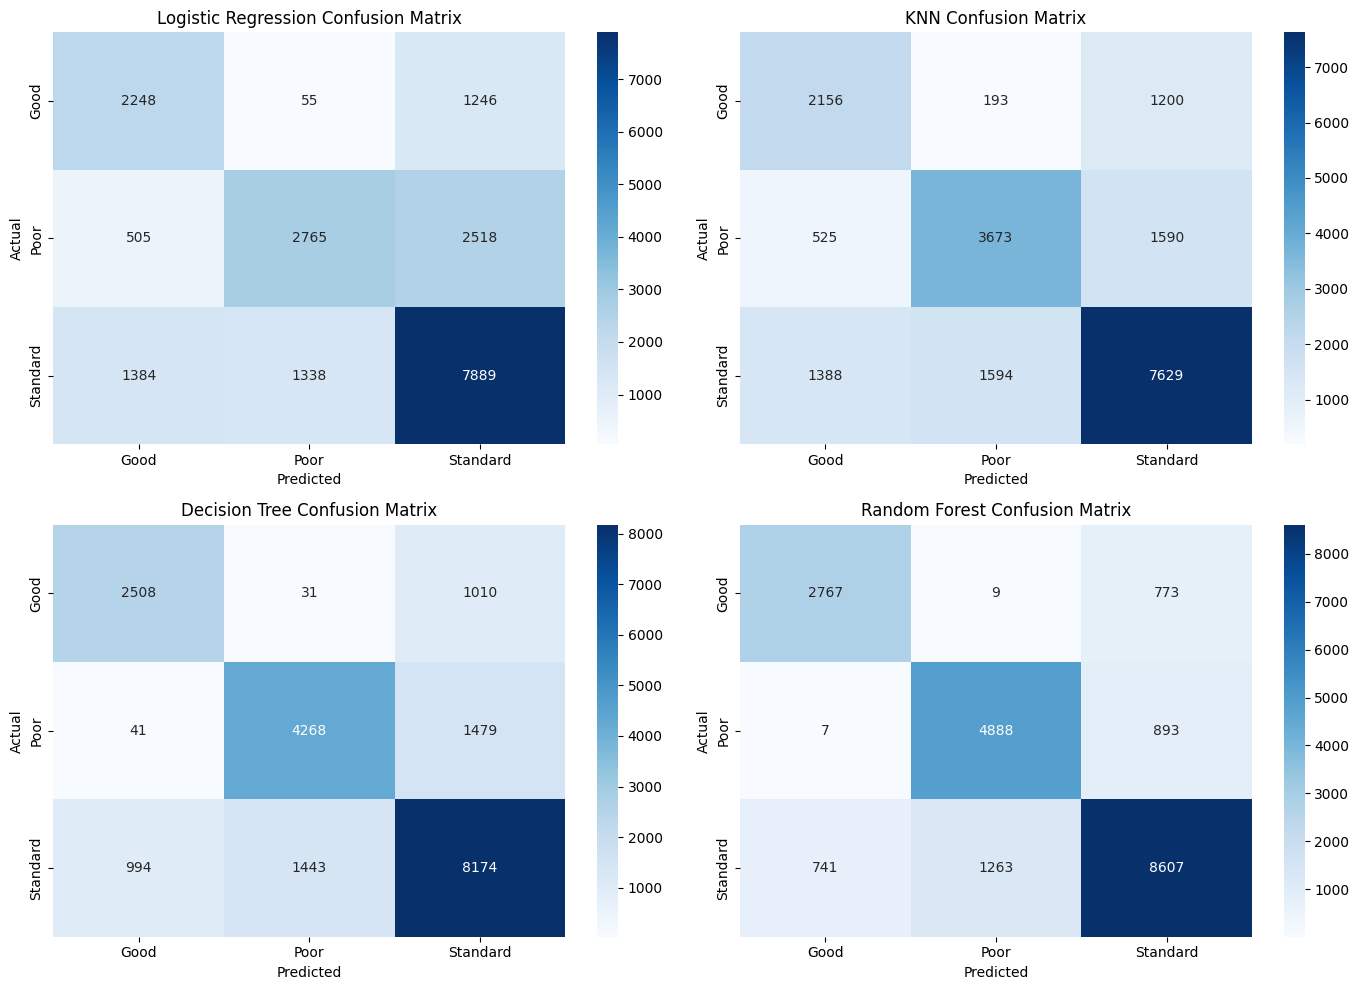

In [213]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

labels = sorted(y_test.unique())

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, (name, model) in enumerate(models.items()):
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred, labels=labels)

    ax = axes[i]
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=labels,
        yticklabels=labels,
        ax=ax
    )
    ax.set_title(f"{name} Confusion Matrix")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.tight_layout()
plt.show()

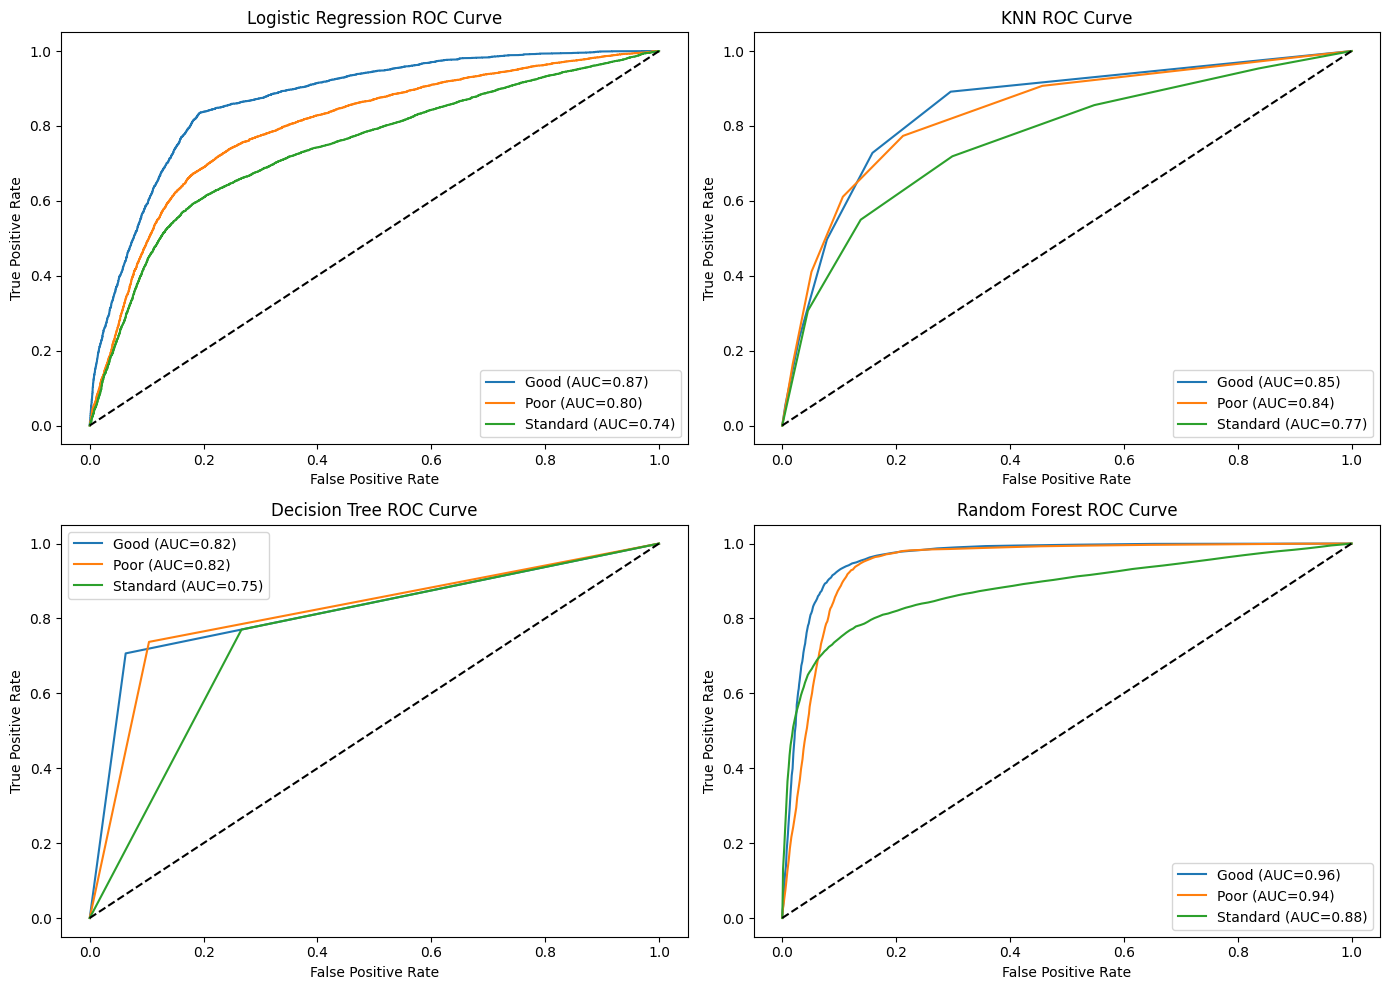

In [214]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, (name, model) in enumerate(models.items()):
    ax = axes[i]

    classes = model.classes_
    y_test_bin = label_binarize(y_test, classes=classes)
    y_score = model.predict_proba(X_test)

    for j, class_name in enumerate(classes):
        fpr, tpr, _ = roc_curve(y_test_bin[:, j], y_score[:, j])
        roc_auc = auc(fpr, tpr)
        ax.plot(fpr, tpr, label=f"{class_name} (AUC={roc_auc:.2f})")

    ax.plot([0, 1], [0, 1], "k--")
    ax.set_title(f"{name} ROC Curve")
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")
    ax.legend()

plt.tight_layout()
plt.show()

In [216]:
from skopt import BayesSearchCV
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(random_state=42)

search_spaces = {
    "n_estimators": (100, 250),
    "max_depth": (5, 20),
    "min_samples_split": (2, 10),
    "min_samples_leaf": (1, 5)
}

bayes_search = BayesSearchCV(
    estimator=rf,
    search_spaces=search_spaces,
    n_iter=10,
    scoring="roc_auc_ovr",
    cv=3,
    n_jobs=-1,
    random_state=42
)

bayes_search.fit(X_train, y_train)

print("Best Parameters:", bayes_search.best_params_)
print("Best AUC:", bayes_search.best_score_)

Best Parameters: OrderedDict({'max_depth': 19, 'min_samples_leaf': 4, 'min_samples_split': 9, 'n_estimators': 162})
Best AUC: 0.9058010017249428


In [217]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

best_rf = RandomForestClassifier(
    **bayes_search.best_params_,
    random_state=42
)

best_rf.fit(X_train, y_train)
y_pred = best_rf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.798024864648085

Classification Report:
              precision    recall  f1-score   support

        Good       0.72      0.78      0.75      3549
        Poor       0.79      0.80      0.80      5788
    Standard       0.83      0.80      0.82     10611

    accuracy                           0.80     19948
   macro avg       0.78      0.80      0.79     19948
weighted avg       0.80      0.80      0.80     19948


Confusion Matrix:
[[2777   16  756]
 [ 174 4644  970]
 [ 885 1228 8498]]
